# Calculating long and short range electrostatics

## Things to change for more than 2 datasets

1. Modify cutoffs (if needed)
2. Add new datasets to new variables
3. Change "columns" variable to reflect number of datasets
4. Copy second cell in each section (long range and short range calculations) for additional datasets
5. Modify labelling of index for more accurate interaction labels
6. Modify plotting section to plot multiple datasets next to each other (make sure they are have the correct spacing apart from each other)

In [2]:
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt
import glob
%matplotlib inline

In [3]:
# #cutoff for electrostat contact
long = 10
short = 4

# #making empty lists to put contact files in
nosalt_type_sims = []

In [4]:
#loading in all electrostat files
sims1 = glob.glob('/data/oonwuzul/abp1-arka17_bound/no_salt/analysis/ES_interaction/dat/*.dat')
sims1_label = 'no salt'
sims2 = glob.glob('/data/oonwuzul/abp1-arka17_bound/salt/abp1-arka17_800mM_salt/ES_interaction/dat/*.dat')
sims2_label = 'salt'

## Calculating long range electrostatic interactions

In [5]:
# Define number of independent sims for bound sims
num_bound_sims = 10

# Define columns once, as they are the same for each DataFrame
columns = [sims1_label + ' long', sims1_label + ' short', sims2_label + ' long', sims2_label + ' short']

# Create dataframes for electrostat fractions and their SEMs
electrostat_frac = pd.DataFrame(columns=columns)
electrostat_frac_sem = pd.DataFrame(columns=columns)

# Create dataframe for total electrostat fraction for each independent bound sim
total_electrostat_frac_bound = pd.DataFrame(0, columns=columns, index=range(0, num_bound_sims))

# Process each binding simulation file
for file_name in sims1:
    # Read data and prepare the dataframe
    df_bound = pd.read_table(file_name, sep=r'\s+')
    df_bound = df_bound.drop(['#Frame'], axis=1)
    df_bound.columns = ['distance']
    electrostat_frac.loc[file_name.split('/')[-1],
                     sims1_label + ' long'] = np.mean((df_bound['distance'] < long) & (df_bound['distance'] > short))
# Calculate the number of snapshots per simulation
    num_bound_snapshots = len(df_bound) // num_bound_sims
# Initialize a list to store the fractions for each simulation
    sim_fractions = []
    for sim in range(0, num_bound_sims):
        df_sim = df_bound[sim*num_bound_snapshots:(sim+1)*num_bound_snapshots]
        # Condition for long-range encounters in each simulation
        long_range_bound_sim = ((df_sim['distance'] < long) & (df_sim['distance'] > short))
        # Calculate total encounters in this simulation
        num_contacts_bound_sim = long_range_bound_sim.sum()
     # Store the fraction for the current simulation
        frac_sim = num_contacts_bound_sim / (len(df_bound)/num_bound_sims)
        sim_fractions.append(frac_sim)

        electrostat_frac.loc[file_name.split('/')[-1],
                     sims1_label + ' long'] = np.mean((df_bound['distance'] < long) & (df_bound['distance'] > short))
# Update the total electrostat fraction for the binding simulations
        total_electrostat_frac_bound.loc[sim, sims1_label + ' long'] += frac_sim
        

    # Calculate the standard error of the mean (SEM) for the simulations
        electrostat_frac_sem.loc[file_name.split('/')[-1], sims1_label + ' long'] = pd.Series(sim_fractions).sem()

/tmp/ipykernel_2761532/2830103836.py:39: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.6261375' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  total_electrostat_frac_bound.loc[sim, sims1_label + ' long'] += frac_sim


In [6]:
# Process each binding simulation file
for file_name in sims2:
    # Read data and prepare the dataframe
    df_bound = pd.read_table(file_name, sep=r'\s+')
    df_bound = df_bound.drop(['#Frame'], axis=1)
    df_bound.columns = ['distance']
    electrostat_frac.loc[file_name.split('/')[-1],
                     sims2_label + ' long'] = np.mean((df_bound['distance'] < long) & (df_bound['distance'] > short))
# Calculate the number of snapshots per simulation
    num_bound_snapshots = len(df_bound) // num_bound_sims
# Initialize a list to store the fractions for each simulation
    sim_fractions = []
    for sim in range(0, num_bound_sims):
        df_sim = df_bound[sim*num_bound_snapshots:(sim+1)*num_bound_snapshots]
        # Condition for long-range encounters in each simulation
        long_range_bound_sim = ((df_sim['distance'] < long) & (df_sim['distance'] > short))
        # Calculate total encounters in this simulation
        num_contacts_bound_sim = long_range_bound_sim.sum()
     # Store the fraction for the current simulation
        frac_sim = num_contacts_bound_sim / (len(df_bound)/num_bound_sims)
        sim_fractions.append(frac_sim)

        electrostat_frac.loc[file_name.split('/')[-1],
                     sims2_label + ' long'] = np.mean((df_bound['distance'] < long) & (df_bound['distance'] > short))
# Update the total electrostat fraction for the binding simulations
        total_electrostat_frac_bound.loc[sim, sims2_label + ' long'] += frac_sim
        

    # Calculate the standard error of the mean (SEM) for the simulations
        electrostat_frac_sem.loc[file_name.split('/')[-1], sims2_label + ' long'] = pd.Series(sim_fractions).sem()

/tmp/ipykernel_2761532/1134443256.py:26: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.4334222222222222' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  total_electrostat_frac_bound.loc[sim, sims2_label + ' long'] += frac_sim


## Calculating short range electrostatic interactions

In [7]:
# Process each binding simulation file
for file_name in sims1:
    # Read data and prepare the dataframe
    df_bound = pd.read_table(file_name, sep=r'\s+')
    df_bound = df_bound.drop(['#Frame'], axis=1)
    df_bound.columns = ['distance']
    electrostat_frac.loc[file_name.split('/')[-1],
                     sims1_label + ' short'] = np.mean((df_bound['distance'] < short))
# Calculate the number of snapshots per simulation
    num_bound_snapshots = len(df_bound) // num_bound_sims
# Initialize a list to store the fractions for each simulation
    sim_fractions = []
    for sim in range(0, num_bound_sims):
        df_sim = df_bound[sim*num_bound_snapshots:(sim+1)*num_bound_snapshots]
        # Condition for long-range encounters in each simulation (formerly less_than_10_encounter_sim)
        short_range_bound_sim = ((df_sim['distance'] < short))
        # Calculate total encounters in this simulation
        num_contacts_bound_sim = short_range_bound_sim.sum()
     # Store the fraction for the current simulation
        frac_sim = num_contacts_bound_sim / (len(df_bound)/num_bound_sims)
        sim_fractions.append(frac_sim)

        electrostat_frac.loc[file_name.split('/')[-1],
                     sims1_label + ' short'] = np.mean((df_bound['distance'] < short))
# Update the total electrostat fraction for the binding simulations
        total_electrostat_frac_bound.loc[sim, sims1_label + ' short'] += frac_sim
        

    # Calculate the standard error of the mean (SEM) for the simulations
        electrostat_frac_sem.loc[file_name.split('/')[-1], sims1_label + ' short'] = pd.Series(sim_fractions).sem()

/tmp/ipykernel_2761532/741931319.py:26: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.0873625' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  total_electrostat_frac_bound.loc[sim, sims1_label + ' short'] += frac_sim


In [8]:
# Process each binding simulation file
for file_name in sims2:
    # Read data and prepare the dataframe
    df_bound = pd.read_table(file_name, sep=r'\s+')
    df_bound = df_bound.drop(['#Frame'], axis=1)
    df_bound.columns = ['distance']
    electrostat_frac.loc[file_name.split('/')[-1],
                     sims2_label + ' short'] = np.mean((df_bound['distance'] < short))
# Calculate the number of snapshots per simulation
    num_bound_snapshots = len(df_bound) // num_bound_sims
# Initialize a list to store the fractions for each simulation
    sim_fractions = []
    for sim in range(0, num_bound_sims):
        df_sim = df_bound[sim*num_bound_snapshots:(sim+1)*num_bound_snapshots]
        # Condition for long-range encounters in each simulation (formerly less_than_10_encounter_sim)
        short_range_bound_sim = ((df_sim['distance'] < short))
        # Calculate total encounters in this simulation
        num_contacts_bound_sim = short_range_bound_sim.sum()
     # Store the fraction for the current simulation
        frac_sim = num_contacts_bound_sim / (len(df_bound)/num_bound_sims)
        sim_fractions.append(frac_sim)

        electrostat_frac.loc[file_name.split('/')[-1],
                     sims2_label + ' short'] = np.mean((df_bound['distance'] < short))
# Update the total electrostat fraction for the binding simulations
        total_electrostat_frac_bound.loc[sim, sims2_label + ' short'] += frac_sim
        

    # Calculate the standard error of the mean (SEM) for the simulations
        electrostat_frac_sem.loc[file_name.split('/')[-1], sims2_label + ' short'] = pd.Series(sim_fractions).sem()

/tmp/ipykernel_2761532/4093630255.py:26: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.044066666666666664' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  total_electrostat_frac_bound.loc[sim, sims2_label + ' short'] += frac_sim


In [9]:
#cutoff for important contacts b/c don't need ones w/o important role 
frac_cutoff = 0.1 
common = pd.DataFrame(columns=[sims1_label + ' sims', sims2_label + ' sims'])
common[sims1_label + ' sims'] = electrostat_frac.iloc[:,0:2].sum(axis=1) > frac_cutoff
common[sims2_label + ' sims'] = electrostat_frac.iloc[:,2:4].sum(axis=1) > frac_cutoff

In [10]:
#making it so only those that meet cutoff show
electrostat_frac['important'] = common.any(axis = 1)
electrostat_frac_subset = electrostat_frac[electrostat_frac['important']]

#did same as above but for sem
electrostat_frac_sem['important'] = common.any(axis = 1)
electrostat_frac_sem_subset = electrostat_frac_sem[electrostat_frac_sem['important']]

In [11]:
#For Fractions
#renaming so not file names and ArkA comes first
electrostat_frac_subset_rn = electrostat_frac_subset.rename(index={"D9_K60.dat": "K(6) to D9", 
                                                            "D15_K60.dat": "K(6) to D15", 
                                                            "D24_K60.dat": "K(6) to D24 ", 
                                                            "D11_K60.dat": "K(6) to D11",
                                                              "D11_K61.dat": "K(5) to D11",
                                                             "D11_K63.dat": "K(3) to D11",
                                                            "D11_K69.dat": "K(-3) to D11",
                                                            "D11_K74.dat": "K(-8) to D11",
                                                            "D11_K76.dat": "K(-10) to D11",
                                                            "D34_K60.dat": "K(6) to D34", 
                                                            "D35_K60.dat": "K(6) to D35", 
                                                            "D44_K60.dat": "K(6) to D44", 
                                                            "D33_K60.dat": "K(6) to D33", 
                                                            "E7_K60.dat": "K(6) to E7", 
                                                            "E14_K60.dat": "K(6) to E14", 
                                                            "E17_K60.dat": "K(6) to E17", 
                                                            "E22_K60.dat": "K(6) to E22", 
                                                            "E30_K60.dat": "K(6) to E30", 
                                                            "E40_K60.dat": "K(6) to E40", 
                                                            "E42_K60.dat": "K(6) to E42", 
                                                             "D9_K61.dat": "K(5) to D9",   
                                                            "D15_K61.dat": "K(5) to D15", 
                                                            "D24_K61.dat": "K(5) to D24 ", 
                                                            "D34_K61.dat": "K(5) to D34", 
                                                            "D35_K61.dat": "K(5) to D35", 
                                                            "D44_K61.dat": "K(5) to D44", 
                                                            "D33_K61.dat": "K(5) to D33", 
                                                            "E7_K61.dat": "K(5) to E7", 
                                                            "E14_K61.dat": "K(5) to E14", 
                                                            "E17_K61.dat": "K(5) to E17", 
                                                            "E22_K61.dat": "K(5) to E22", 
                                                            "E30_K61.dat": "K(5) to E30", 
                                                            "E40_K61.dat": "K(5) to E40", 
                                                            "E42_K61.dat": "K(5) to E42",
                                                            "D9_K63.dat": "K(3) to D9",
                                                            "D15_K63.dat": "K(3) to D15", 
                                                            "D24_K63.dat": "K(3) to D24 ", 
                                                            "D34_K63.dat": "K(3) to D34", 
                                                            "D35_K63.dat": "K(3) to D35", 
                                                            "D44_K63.dat": "K(3) to D44", 
                                                            "D33_K63.dat": "K(3) to D33", 
                                                            "E7_K63.dat": "K(3) to E7", 
                                                            "E14_K63.dat": "K(3) to E14", 
                                                            "E17_63.dat": "K(3) to E17", 
                                                            "E22_K63.dat": "K(3) to E22", 
                                                            "E30_K63.dat": "K(3) to E30", 
                                                            "E40_K63.dat": "K(3) to E40", 
                                                            "E42_K63.dat": "K(3) to E42",
                                                            "D9_K69.dat": "K(-3) to D9",
                                                            "D15_K69.dat": "K(-3) to D15", 
                                                            "D24_K69.dat": "K(-3) to D24 ", 
                                                            "D34_K69.dat": "K(-3) to D34", 
                                                            "D35_K69.dat": "K(-3) to D35", 
                                                            "D44_K69.dat": "K(-3) to D44", 
                                                            "D33_K69.dat": "K(-3) to D33", 
                                                            "E7_K69.dat": "K(-3) to E7", 
                                                            "E14_K69.dat": "K(-3) to E14", 
                                                            "E17_K69.dat": "K(-3) to E17", 
                                                            "E22_K69.dat": "K(-3) to E22", 
                                                            "E30_K69.dat": "K(-3) to E30", 
                                                            "E40_K69.dat": "K(-3) to E40", 
                                                            "E42_K69.dat": "K(-3) to E42",
                                                            "D9_K74.dat": "K(-8) to D9",
                                                            "D15_K74.dat": "K(-8) to D15", 
                                                            "D24_K74.dat": "K(-8) to D24 ", 
                                                            "D34_K74.dat": "K(-8) to D34", 
                                                            "D35_K74.dat": "K(-8) to D35", 
                                                            "D44_K74.dat": "K(-8) to D44", 
                                                            "D33_K74.dat": "K(-8) to D33", 
                                                            "E7_K74.dat": "K(-8) to E7", 
                                                            "E14_K74.dat": "K(-8) to E14", 
                                                            "E17_K74.dat": "K(-8) to E17", 
                                                            "E22_K74.dat": "K(-8) to E22", 
                                                            "E30_K74.dat": "K(-8) to E30", 
                                                            "E40_K74.dat": "K(-8) to E40", 
                                                            "E42_K74.dat": "K(-8) to E42",
                                                            "D9_K76.dat": "K(-10) to D9",
                                                            "D15_K76.dat": "K(-10) to D15", 
                                                            "D24_K76.dat": "K(-10) to D24 ", 
                                                            "D34_K76.dat": "K(-10) to D34", 
                                                            "D35_K76.dat": "K(-10) to D35", 
                                                            "D44_K76.dat": "K(-10) to D44", 
                                                            "D33_K76.dat": "K(-10) to D33", 
                                                            "E7_K76.dat": "K(-10) to E7", 
                                                            "E14_K76.dat": "K(-10) to E14", 
                                                            "E17_K76.dat": "K(-10) to E17", 
                                                            "E22_K76.dat": "K(-10) to E22", 
                                                            "E30_K76.dat": "K(-10) to E30", 
                                                            "E40_K76.dat": "K(-10) to E40", 
                                                            "E42_K76.dat": "K(-10) to E42",
                                                             })
#rearranging index so in order of ArkA17 and then within that increasing of SH3
electrostat_frac_subset_rn = electrostat_frac_subset_rn.reindex(["K(6) to D9", 
                                                       "K(6) to D11",
                                                     "K(6) to D15",
                                                       "K(6) to D24",
                                                       "K(6) to D33", 
                                                       "K(6) to D34", 
                                                       "K(6) to D35",
                                                       "K(6) to D44",
                                                       "K(6) to E7",
                                                       "K(6) to E14", 
                                                       "K(6) to E17", 
                                                       "K(6) to E22", 
                                                       "K(6) to E30", 
                                                       "K(6) to E40", 
                                                       "K(6) to E42",
                                                        "K(5) to D9", 
                                                        "K(5) to D11",
                                                        "K(5) to D15",
                                                       "K(5) to D24",
                                                       "K(5) to D33", 
                                                       "K(5) to D34", 
                                                       "K(5) to D35",
                                                       "K(5) to D44",
                                                       "K(5) to E7",
                                                       "K(5) to E14", 
                                                       "K(5) to E17", 
                                                       "K(5) to E22", 
                                                       "K(5) to E30", 
                                                       "K(5) to E40", 
                                                       "K(5) to E42",
                                                        "K(3) to D9",
                                                        "K(3) to D11",
                                                        "K(3) to D15",
                                                       "K(3) to D24",
                                                       "K(3) to D33", 
                                                       "K(3) to D34", 
                                                       "K(3) to D35",
                                                       "K(3) to D44",
                                                       "K(3) to E7",
                                                       "K(3) to E14", 
                                                       "K(3) to E17", 
                                                       "K(3) to E22", 
                                                       "K(3) to E30", 
                                                       "K(3) to E40", 
                                                       "K(3) to E42",
                                                        "K(-3) to D9",
                                                        "K(-3) to D11",
                                                        "K(-3) to D15",
                                                       "K(-3) to D24",
                                                       "K(-3) to D33", 
                                                       "K(-3) to D34", 
                                                       "K(-3) to D35",
                                                       "K(-3) to D44",
                                                       "K(-3) to E7",
                                                       "K(-3) to E14", 
                                                       "K(-3) to E17", 
                                                       "K(-3) to E22", 
                                                       "K(-3) to E30", 
                                                       "K(-3) to E40", 
                                                       "K(-3) to E42",
                                                        "K(-8) to D9",
                                                        "K(-8) to D11",
                                                        "K(-8) to D15",
                                                       "K(-8) to D24",
                                                       "K(-8) to D33", 
                                                       "K(-8) to D34", 
                                                       "K(-8) to D35",
                                                       "K(-8) to D44",
                                                       "K(-8) to E7",
                                                       "K(-8) to E14", 
                                                       "K(-8) to E17", 
                                                       "K(-8) to E22", 
                                                       "K(-8) to E30", 
                                                       "K(-8) to E40", 
                                                       "K(-8) to E42",
                                                        "K(-10) to D9",
                                                        "K(-10) to D11",
                                                        "K(-10) to D15",
                                                       "K(-10) to D24",
                                                       "K(-10) to D33", 
                                                       "K(-10) to D34", 
                                                       "K(-10) to D35",
                                                       "K(-10) to D44",
                                                       "K(-10) to E7",
                                                       "K(-10) to E14", 
                                                       "K(-10) to E17", 
                                                       "K(-10) to E22", 
                                                       "K(-10) to E30", 
                                                       "K(-10) to E40", 
                                                       "K(-10) to E42",
                                                       ])
electrostat_frac_subset_rn = electrostat_frac_subset_rn.dropna(axis=0)
electrostat_frac_subset_rn

,no salt long,no salt short,salt long,salt short,important
K(6) to D9,0.650343,0.082315,0.473031,0.035341,True
K(6) to E7,0.410833,0.122399,0.350389,0.099209,True
K(6) to E22,0.321173,0.506301,0.286926,0.380049,True
K(5) to D9,0.169448,0.003338,0.116899,0.0039,True
K(5) to E7,0.49859,0.110365,0.430911,0.069376,True
K(5) to E22,0.216705,0.1353,0.202196,0.108297,True
K(3) to D9,0.467909,0.526321,0.536276,0.455097,True
K(3) to D11,0.93663,0.041931,0.92039,0.040319,True
K(3) to E22,0.635243,0.000003,0.561349,0.0,True
K(-3) to D11,0.128715,0.0,0.080737,0.0,True


In [12]:
# For sem
#renaming so not file names and ArkA comes first
electrostat_frac_sem_subset_rn = electrostat_frac_sem_subset.rename(index={"D9_K60.dat": "K(6) to D9", 
                                                            "D9_K60.dat": "K(6) to D9",
                                                             "D11_K60.dat": "K(6) to D11",
                                                              "D11_K61.dat": "K(5) to D11",
                                                             "D11_K63.dat": "K(3) to D11",
                                                            "D11_K69.dat": "K(-3) to D11",
                                                            "D11_K74.dat": "K(-8) to D11",
                                                            "D11_K76.dat": "K(-10) to D11",
                                                            "D15_K60.dat": "K(6) to D15", 
                                                            "D24_K60.dat": "K(6) to D24 ", 
                                                            "D34_K60.dat": "K(6) to D34", 
                                                            "D35_K60.dat": "K(6) to D35", 
                                                            "D44_K60.dat": "K(6) to D44", 
                                                            "D33_K60.dat": "K(6) to D33", 
                                                            "E7_K60.dat": "K(6) to E7", 
                                                            "E14_K60.dat": "K(6) to E14", 
                                                            "E17_K60.dat": "K(6) to E17", 
                                                            "E22_K60.dat": "K(6) to E22", 
                                                            "E30_K60.dat": "K(6) to E30", 
                                                            "E40_K60.dat": "K(6) to E40", 
                                                            "E42_K60.dat": "K(6) to E42", 
                                                             "D9_K61.dat": "K(5) to D9",
                                                            "D15_K61.dat": "K(5) to D15", 
                                                            "D24_K61.dat": "K(5) to D24 ", 
                                                            "D34_K61.dat": "K(5) to D34", 
                                                            "D35_K61.dat": "K(5) to D35", 
                                                            "D44_K61.dat": "K(5) to D44", 
                                                            "D33_K61.dat": "K(5) to D33", 
                                                            "E7_K61.dat": "K(5) to E7", 
                                                            "E14_K61.dat": "K(5) to E14", 
                                                            "E17_K61.dat": "K(5) to E17", 
                                                            "E22_K61.dat": "K(5) to E22", 
                                                            "E30_K61.dat": "K(5) to E30", 
                                                            "E40_K61.dat": "K(5) to E40", 
                                                            "E42_K61.dat": "K(5) to E42",
                                                            "D9_K63.dat": "K(3) to D9",
                                                            "D15_K63.dat": "K(3) to D15", 
                                                            "D24_K63.dat": "K(3) to D24 ", 
                                                            "D34_K63.dat": "K(3) to D34", 
                                                            "D35_K63.dat": "K(3) to D35", 
                                                            "D44_K63.dat": "K(3) to D44", 
                                                            "D33_K63.dat": "K(3) to D33", 
                                                            "E7_K63.dat": "K(3) to E7", 
                                                            "E14_K63.dat": "K(3) to E14", 
                                                            "E17_K63.dat": "K(3) to E17", 
                                                            "E22_K63.dat": "K(3) to E22", 
                                                            "E30_K63.dat": "K(3) to E30", 
                                                            "E40_K63.dat": "K(3) to E40", 
                                                            "E42_K63.dat": "K(3) to E42",
                                                            "D9_K69.dat": "K(-3) to D9",
                                                            "D15_K69.dat": "K(-3) to D15", 
                                                            "D24_K69.dat": "K(-3) to D24 ", 
                                                            "D34_K69.dat": "K(-3) to D34", 
                                                            "D35_K69.dat": "K(-3) to D35", 
                                                            "D44_K69.dat": "K(-3) to D44", 
                                                            "D33_K69.dat": "K(-3) to D33", 
                                                            "E7_K69.dat": "K(-3) to E7", 
                                                            "E14_K69.dat": "K(-3) to E14", 
                                                            "E17_K69.dat": "K(-3) to E17", 
                                                            "E22_K69.dat": "K(-3) to E22", 
                                                            "E30_K69.dat": "K(-3) to E30", 
                                                            "E40_K69.dat": "K(-3) to E40", 
                                                            "E42_K69.dat": "K(-3) to E42",
                                                            "D9_K74.dat": "K(-8) to D9",
                                                            "D15_K74.dat": "K(-8) to D15", 
                                                            "D24_K74.dat": "K(-8) to D24 ", 
                                                            "D34_K74.dat": "K(-8) to D34", 
                                                            "D35_K74.dat": "K(-8) to D35", 
                                                            "D44_K74.dat": "K(-8) to D44", 
                                                            "D33_K74.dat": "K(-8) to D33", 
                                                            "E7_K74.dat": "K(-8) to E7", 
                                                            "E14_K74.dat": "K(-8) to E14", 
                                                            "E17_K74.dat": "K(-8) to E17", 
                                                            "E22_K74.dat": "K(-8) to E22", 
                                                            "E30_K74.dat": "K(-8) to E30", 
                                                            "E40_K74.dat": "K(-8) to E40", 
                                                            "E42_K74.dat": "K(-8) to E42",
                                                            "D9_K76.dat": "K(-10) to D9",
                                                            "D15_K76.dat": "K(-10) to D15", 
                                                            "D24_K76.dat": "K(-10) to D24 ", 
                                                            "D34_K76.dat": "K(-10) to D34", 
                                                            "D35_K76.dat": "K(-10) to D35", 
                                                            "D44_K76.dat": "K(-10) to D44", 
                                                            "D33_K76.dat": "K(-10) to D33", 
                                                            "E7_K76.dat": "K(-10) to E7", 
                                                            "E14_K76.dat": "K(-10) to E14", 
                                                            "E17_K76.dat": "K(-10) to E17", 
                                                            "E22_K76.dat": "K(-10) to E22", 
                                                            "E30_K76.dat": "K(-10) to E30", 
                                                            "E40_K76.dat": "K(-10) to E40", 
                                                            "E42_K76.dat": "K(-10) to E42",
                                                             })
#rearranging index so in order of ArkA17 and then within that increasing of SH3
electrostat_frac_sem_subset_rn = electrostat_frac_sem_subset_rn.reindex(["K(6) to D9", 
                                                        "K(6) to D11",
                                                     "K(6) to D15",
                                                       "K(6) to D24",
                                                       "K(6) to D33", 
                                                       "K(6) to D34", 
                                                       "K(6) to D35",
                                                       "K(6) to D44",
                                                       "K(6) to E7",
                                                       "K(6) to E14", 
                                                       "K(6) to E17", 
                                                       "K(6) to E22", 
                                                       "K(6) to E30", 
                                                       "K(6) to E40", 
                                                       "K(6) to E42",
                                                        "K(5) to D9", 
                                                        "K(5) to D11",
                                                        "K(5) to D15",
                                                       "K(5) to D24",
                                                       "K(5) to D33", 
                                                       "K(5) to D34", 
                                                       "K(5) to D35",
                                                       "K(5) to D44",
                                                       "K(5) to E7",
                                                       "K(5) to E14", 
                                                       "K(5) to E17", 
                                                       "K(5) to E22", 
                                                       "K(5) to E30", 
                                                       "K(5) to E40", 
                                                       "K(5) to E42",
                                                        "K(3) to D9",
                                                        "K(3) to D11",
                                                        "K(3) to D15",
                                                       "K(3) to D24",
                                                       "K(3) to D33", 
                                                       "K(3) to D34", 
                                                       "K(3) to D35",
                                                       "K(3) to D44",
                                                       "K(3) to E7",
                                                       "K(3) to E14", 
                                                       "K(3) to E17", 
                                                       "K(3) to E22", 
                                                       "K(3) to E30", 
                                                       "K(3) to E40", 
                                                       "K(3) to E42",
                                                        "K(-3) to D9",
                                                        "K(-3) to D11",
                                                        "K(-3) to D15",
                                                       "K(-3) to D24",
                                                       "K(-3) to D33", 
                                                       "K(-3) to D34", 
                                                       "K(-3) to D35",
                                                       "K(-3) to D44",
                                                       "K(-3) to E7",
                                                       "K(-3) to E14", 
                                                       "K(-3) to E17", 
                                                       "K(-3) to E22", 
                                                       "K(-3) to E30", 
                                                       "K(-3) to E40", 
                                                       "K(-3) to E42",
                                                        "K(-8) to D9",
                                                        "K(-8) to D11",
                                                        "K(-8) to D15",
                                                       "K(-8) to D24",
                                                       "K(-8) to D33", 
                                                       "K(-8) to D34", 
                                                       "K(-8) to D35",
                                                       "K(-8) to D44",
                                                       "K(-8) to E7",
                                                       "K(-8) to E14", 
                                                       "K(-8) to E17", 
                                                       "K(-8) to E22", 
                                                       "K(-8) to E30", 
                                                       "K(-8) to E40", 
                                                       "K(-8) to E42",
                                                        "K(-10) to D9",
                                                        "K(-10) to D11",
                                                        "K(-10) to D15",
                                                       "K(-10) to D24",
                                                       "K(-10) to D33", 
                                                       "K(-10) to D34", 
                                                       "K(-10) to D35",
                                                       "K(-10) to D44",
                                                       "K(-10) to E7",
                                                       "K(-10) to E14", 
                                                       "K(-10) to E17", 
                                                       "K(-10) to E22", 
                                                       "K(-10) to E30", 
                                                       "K(-10) to E40", 
                                                       "K(-10) to E42",
                                                        ])
                                                    
electrostat_frac_sem_subset_rn = electrostat_frac_sem_subset_rn.dropna(axis=0)
electrostat_frac_sem_subset_rn

,no salt long,no salt short,salt long,salt short,important
K(6) to D9,0.009442,0.004716,0.019865,0.004588,True
K(6) to E7,0.010317,0.006993,0.017277,0.00493,True
K(6) to E22,0.004569,0.009875,0.005775,0.01245,True
K(5) to D9,0.010979,0.000758,0.008585,0.001255,True
K(5) to E7,0.00753,0.003329,0.013657,0.005247,True
K(5) to E22,0.007109,0.009018,0.009753,0.008356,True
K(3) to D9,0.018027,0.017814,0.037425,0.036682,True
K(3) to D11,0.007634,0.008486,0.015656,0.017542,True
K(3) to E22,0.013166,0.000002,0.015736,0.0,True
K(-3) to D11,0.031575,0.0,0.016752,0.0,True


## Plot of fraction of ensemble for specific electrostatic interactions

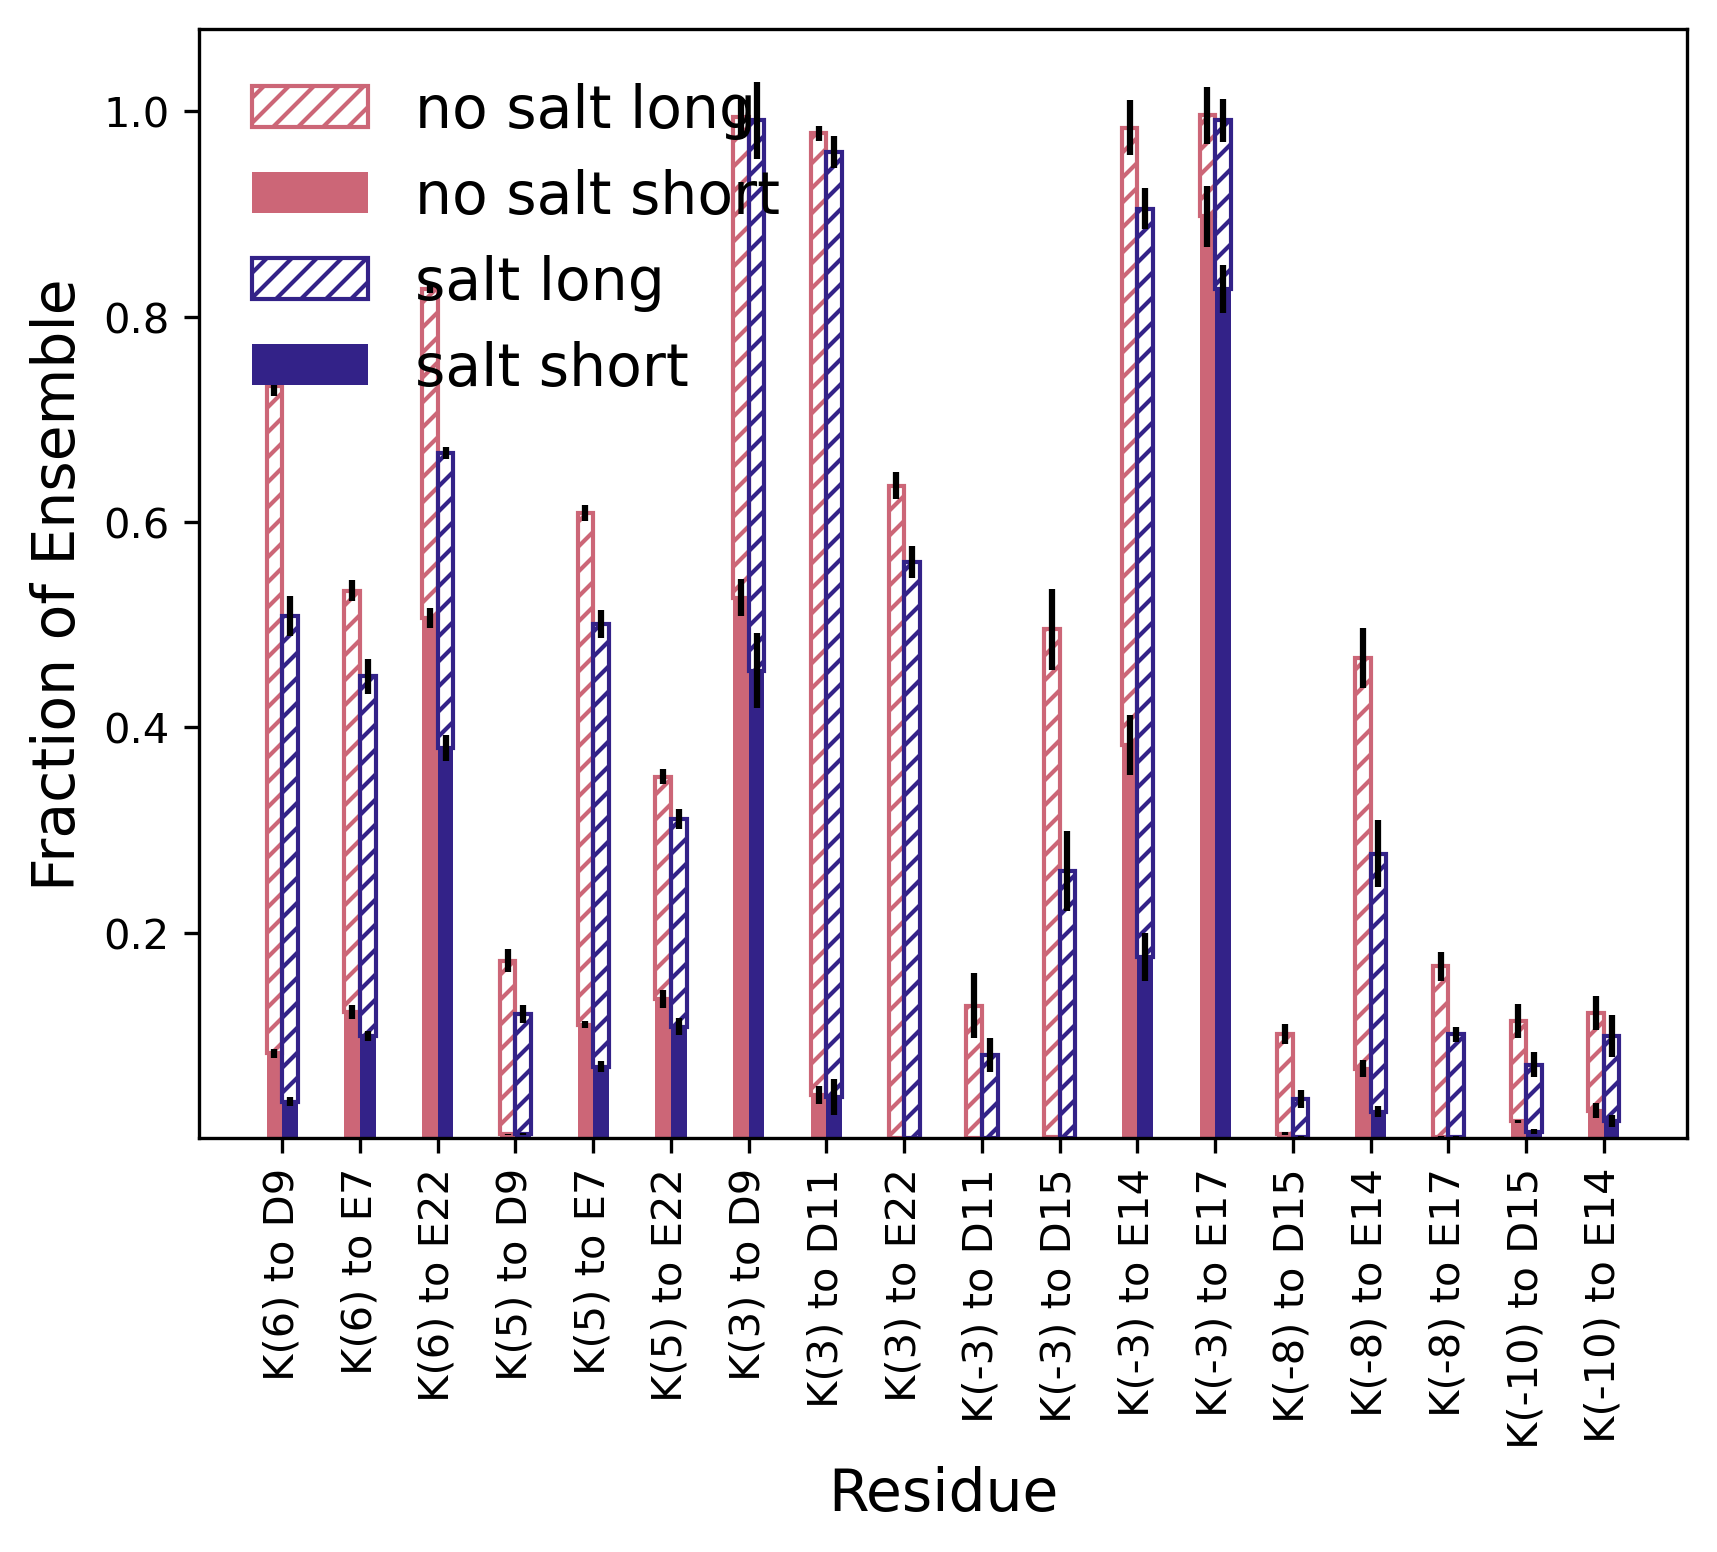

In [13]:
plt.figure(dpi=300)
plt.rcParams['figure.figsize'] = [11, 4]

# Data
x = np.arange(len(electrostat_frac_subset_rn.dropna(axis=0).index))  # X coordinates for each group
width = 0.20  # Width of the bars

# Plotting the "long" bars (only for "nosalt sims")
plt.bar(x - width/2, electrostat_frac_subset_rn.dropna(axis=0)[sims1_label + ' long'], width, 
        bottom=electrostat_frac_subset_rn.dropna(axis=0)[sims1_label + ' short'], edgecolor='#CC6677', facecolor='none', hatch='////', 
        yerr=electrostat_frac_sem_subset_rn.dropna(axis=0)[sims1_label + ' long'], label=sims1_label + ' long')

# Plotting the "short" bars (only for "nosalt sims")
plt.bar(x - width/2, electrostat_frac_subset_rn.dropna(axis=0)[sims1_label + ' short'], width, color='#CC6677', 
        yerr=electrostat_frac_sem_subset_rn.dropna(axis=0)[sims1_label + ' short'], label=sims1_label + ' short')

# Plotting the "long" bars (only for "nosalt sims")
plt.bar(x + width/2, electrostat_frac_subset_rn.dropna(axis=0)[sims2_label + ' long'], width, 
        bottom=electrostat_frac_subset_rn.dropna(axis=0)[sims2_label + ' short'], edgecolor='#332288', facecolor='none', hatch='////', 
        yerr=electrostat_frac_sem_subset_rn.dropna(axis=0)[sims2_label + ' long'], label=sims2_label + ' long')

# Plotting the "short" bars (only for "nosalt sims")
plt.bar(x + width/2, electrostat_frac_subset_rn.dropna(axis=0)[sims2_label + ' short'], width, color='#332288', 
        yerr=electrostat_frac_sem_subset_rn.dropna(axis=0)[sims2_label + ' short'], label=sims2_label + ' short')

# Set the y-axis limits
#plt.ylim(bottom=0, top=1.05)

# Add legend, xlabel, ylabel, and title
plt.legend(fontsize=14, frameon=False)
plt.xlabel('Residue', fontsize=14)                 
plt.ylabel('Fraction of Ensemble', fontsize=14)
# plt.title('Contact Between Charged Residues', fontsize=14)

# Set x-axis ticks as original index
plt.xticks(x, electrostat_frac_subset_rn.dropna(axis=0).index)

# Rotate x-axis labels for better visibility if needed
plt.xticks(rotation=90)

# Show the plot
plt.show()
#plt.savefig("Stacked_electrostats_bound_encounter_ArkA12_with_errbars.png", dpi= 300)

## Plot of average number of Electrostatic interaction

Text(0.5, 1.0, 'ArkA17 Bound')

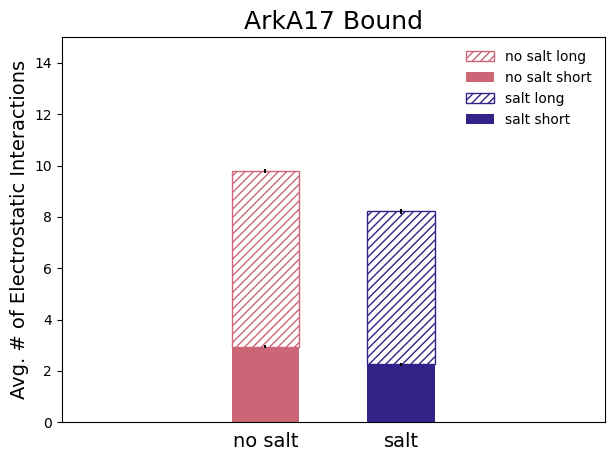

In [14]:
x = np.arange(1)  # X coordinates for each group
#print(x)
width = 0.25

plt.figure(figsize=(7,5))
#ax = total_electrostat_frac_bound.mean().plot.bar(yerr=total_electrostat_frac_bound.sem(), width=0.5, rot=45)
#fig = plt.gcf()
#ax.set_ylabel('Avg. # Electrostatic Interactions')
#plt.bar(x - width/2, total_electrostat_frac_bound.mean(), width, 
        #yerr=total_electrostat_frac_bound.sem())
    
# Plotting the "long" bars (only for "nosalt sims")
plt.bar(x - width, total_electrostat_frac_bound[sims1_label + ' long'].mean(), width, 
        bottom=total_electrostat_frac_bound[sims1_label + ' short'].mean(), edgecolor='#CC6677', facecolor='none', hatch='////', 
        yerr=total_electrostat_frac_bound[sims1_label + ' long'].sem(), label=sims1_label + ' long')

# Plotting the "short" bars (only for "nosalt sims")
plt.bar(x - width, total_electrostat_frac_bound[sims1_label + ' short'].mean(), width, color='#CC6677',
        yerr=total_electrostat_frac_bound[sims1_label + ' short'].sem(), label=sims1_label + ' short')

plt.bar(x + width, total_electrostat_frac_bound[sims2_label + ' long'].mean(), width, 
        bottom=total_electrostat_frac_bound[sims2_label + ' short'].mean(), edgecolor='#332288', facecolor='none', hatch='////', 
        yerr=total_electrostat_frac_bound[sims2_label + ' long'].sem(), label=sims2_label + ' long')

# Plotting the "short" bars (only for "nosalt sims")
plt.bar(x + width, total_electrostat_frac_bound[sims2_label + ' short'].mean(), width, color='#332288',
        yerr=total_electrostat_frac_bound[sims2_label + ' short'].sem(), label=sims2_label + ' short')

plt.xlim(-1,1)
plt.ylim(0,15)
plt.xticks([-width, width], ["no salt", "salt"], fontsize=14)
plt.tick_params(bottom=False)
# Set x-axis ticks as original index
#plt.xticks([x - 3.015*width , x - 1.0125*width,0.985*width, 2.985*width],["wildtype"], fontsize=14)

# Add legend, xlabel, ylabel, and title
plt.legend(fontsize=10,frameon=False, )          
plt.ylabel('Avg. # of Electrostatic Interactions', fontsize=14)
plt.title('ArkA17 Bound', fontsize=18)

## Means

In [15]:
total_electrostat_frac_bound[sims1_label + ' long'].mean()

6.850177499999999

In [16]:
total_electrostat_frac_bound[sims1_label + ' short'].mean()

2.94563

In [17]:
total_electrostat_frac_bound[sims2_label + ' long'].mean()

5.956762222222222

In [18]:
total_electrostat_frac_bound[sims2_label + ' short'].mean()

2.2605022222222226

## SEMs

In [19]:
total_electrostat_frac_bound[sims1_label + ' long'].sem()

0.06720832686161043

In [20]:
total_electrostat_frac_bound[sims1_label + ' short'].sem()

0.05279667804417255

In [21]:
total_electrostat_frac_bound[sims2_label + ' long'].sem()

0.10709908955129369

In [22]:
total_electrostat_frac_bound[sims2_label + ' short'].sem()

0.05129576431867485

## p-value calculations

In [23]:
total_electrostat_frac_bound[sims1_label + ' long']

0    6.937571
1    6.777971
2    6.710413
3    6.546571
4    6.817663
5    6.756525
6    7.324783
7    6.976250
8    6.949321
9    6.704708
Name: no salt long, dtype: float64

In [25]:
total_electrostat_frac_bound

,no salt long,no salt short,salt long,salt short
0,6.937571,2.907304,5.590156,2.060467
1,6.777971,2.961079,6.560967,2.317456
2,6.710413,2.976508,5.936578,2.478922
3,6.546571,2.706158,5.793511,2.017811
4,6.817663,3.167996,5.731256,2.262078
5,6.756525,2.990725,6.178000,2.206656
6,7.324783,2.659683,6.164222,2.390500
7,6.976250,3.129233,6.108511,2.492489
8,6.949321,2.874621,6.110156,2.229300
9,6.704708,3.082992,5.394267,2.149344


In [26]:
# ArkA12 binding_salt effect of NaCl (JUST short)
ArkA12_avg_values = np.concatenate([(total_electrostat_frac_bound.dropna(axis=0)[sims1_label + ' short']).values,
                                           (total_electrostat_frac_bound.dropna(axis=0)[sims2_label + ' short']).values])
#calculate the real difference, no salt minus salt
diff_ArkA12_short = (total_electrostat_frac_bound.dropna(axis=0)[sims1_label + ' short']).values.mean()\
        - (total_electrostat_frac_bound.dropna(axis=0)[sims2_label + ' short']).values.mean()

print("Short ArkA17 bound 800 mM NaCl vs no-salt difference = " , diff_ArkA12_short)

#sample 10000 times and calculate differences
numsample = 10000
diff_ArkA12_samples = [0]*numsample
diff_ArkA12_samples_larger = [0]*numsample
for sample in range(0,len(diff_ArkA12_samples)):
    random_groups = np.random.permutation(ArkA12_avg_values)
    diff_ArkA12_samples[sample] = (np.mean(random_groups[0:num_bound_sims]) 
             - np.mean(random_groups[num_bound_sims:num_bound_sims 
                                                + num_bound_sims]))
    if diff_ArkA12_samples[sample] >= diff_ArkA12_short:
        diff_ArkA12_samples_larger[sample] = 1

#calculate p-value
pval_diff_ArkA12 = (1 + np.sum(diff_ArkA12_samples_larger))/(numsample + 1)
print("p-value = " , pval_diff_ArkA12)

Short ArkA17 bound 800 mM NaCl vs no-salt difference =  0.6851277777777773
p-value =  9.999000099990002e-05


In [27]:
# ArkA12 binding_salt effect of NaCl (JUST long)
ArkA12_avg_values = np.concatenate([(total_electrostat_frac_bound.dropna(axis=0)[sims1_label + ' long']).values,
                                           (total_electrostat_frac_bound.dropna(axis=0)[sims2_label + ' long']).values])
#calculate the real difference, no salt minus salt
diff_ArkA12_long = (total_electrostat_frac_bound.dropna(axis=0)[sims1_label + ' long']).values.mean()\
        - (total_electrostat_frac_bound.dropna(axis=0)[sims2_label + ' long']).values.mean()

print("Long ArkA17 bound 800 mM NaCl vs no-salt difference = " , diff_ArkA12_long)

#sample 10000 times and calculate differences
numsample = 10000
diff_ArkA12_samples = [0]*numsample
diff_ArkA12_samples_larger = [0]*numsample
for sample in range(0,len(diff_ArkA12_samples)):
    random_groups = np.random.permutation(ArkA12_avg_values)
    diff_ArkA12_samples[sample] = (np.mean(random_groups[0:num_bound_sims]) 
             - np.mean(random_groups[num_bound_sims:num_bound_sims 
                                                + num_bound_sims]))
    if diff_ArkA12_samples[sample] >= diff_ArkA12_long:
        diff_ArkA12_samples_larger[sample] = 1

#calculate p-value
pval_diff_ArkA12 = (1 + np.sum(diff_ArkA12_samples_larger))/(numsample + 1)
print("p-value = " , pval_diff_ArkA12)

Long ArkA17 bound 800 mM NaCl vs no-salt difference =  0.8934152777777769
p-value =  9.999000099990002e-05


In [24]:
# ArkA12 binding_salt effect of NaCl (JUST LONG)
total_nosalt = (total_electrostat_frac_bound.dropna(axis=0)[sims1_label + ' long']).values + (total_electrostat_frac_bound.dropna(axis=0)[sims1_label + ' short']).values
total_salt = (total_electrostat_frac_bound.dropna(axis=0)[sims2_label + ' long']).values + (total_electrostat_frac_bound.dropna(axis=0)[sims2_label + ' short']).values

ArkA12_avg_values = np.concatenate([total_nosalt, total_salt])

#calculate the real difference, no salt minus salt
diff_ArkA12_total = total_nosalt.mean() - total_salt.mean()

print("ArkA17 bound 800 mM NaCl vs no-salt difference = " , diff_ArkA12_total)

#sample 10000 times and calculate differences
numsample = 10000
diff_ArkA12_samples = [0]*numsample
diff_ArkA12_samples_larger = [0]*numsample
for sample in range(0,len(diff_ArkA12_samples)):
    random_groups = np.random.permutation(ArkA12_avg_values)
    diff_ArkA12_samples[sample] = (np.mean(random_groups[0:num_bound_sims]) 
             - np.mean(random_groups[num_bound_sims:num_bound_sims 
                                                + num_bound_sims]))
    if diff_ArkA12_samples[sample] >= diff_ArkA12_total:
        diff_ArkA12_samples_larger[sample] = 1

#calculate p-value
pval_diff_ArkA12 = (1 + np.sum(diff_ArkA12_samples_larger))/(numsample + 1)
print("p-value = " , pval_diff_ArkA12)

ArkA17 bound 800 mM NaCl vs no-salt difference =  1.5785430555555582
p-value =  9.999000099990002e-05
